In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Load the cleaned dataset from Phase 3
df = pd.read_parquet("../data/processed/postings_clean.parquet")
print(f"Loaded: {len(df):,} postings, {len(df.columns)} columns")
print(f"\nColumns: {df.columns.tolist()}")

Loaded: 2,835 postings, 23 columns

Columns: ['salary_is_predicted', 'salary_min', 'title', 'created', 'id', 'salary_max', 'description', '_collected_at', 'longitude', 'contract_type', 'latitude', 'contract_time', 'category_label', 'company_name', 'location_full', 'location_area', 'category_tag', 'found_under_keywords', 'n_keywords_matched', 'title_length', 'description_length', 'description_word_count', 'salary_midpoint']


In [2]:
# Combine title and description into one text per posting
df["text_for_embedding"] = df["title"].fillna("") + ". " + df["description"].fillna("")

# Quick sanity check
print("Sample text-for-embedding (first 3):")
for i in range(3):
    text = df.iloc[i]["text_for_embedding"]
    print(f"\n[{df.iloc[i]['title']}]")
    print(f"  Word count: {len(text.split())}")
    print(f"  Preview: {text[:200]}...")

Sample text-for-embedding (first 3):

[Data Analyst]
  Word count: 79
  Preview: Data Analyst. The Vacancy Background As part of our ongoing digital transformation, we are migrating our existing on-premises Microsoft SQL Server estate into Azure SQL, Microsoft Fabric, and Power BI...

[Data Analyst]
  Word count: 84
  Preview: Data Analyst. Data Analyst Contract up to 31/12/2026 Based in Filton Offering £50ph Inside IR35 Do you have experience with Jira or GitHub? Do you have experience with Palantir Foundry (Skywise) or Ex...

[Data Analyst]
  Word count: 82
  Preview: Data Analyst. Why Greencore? Following the combination with Bakkavor in January 2026, we're one of the UK's leading creators of convenience food, driven by a simple purpose: to make everyday taste bet...


In [3]:
from sentence_transformers import SentenceTransformer

# all-MiniLM-L6-v2 is the standard, well-tested model for English text clustering
# Small (~80MB), fast, produces 384-dimensional embeddings
print("Loading sentence-transformer model (first time may download ~80MB)...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded.")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading sentence-transformer model (first time may download ~80MB)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Embedding dimension: 384


In [4]:
import time

texts = df["text_for_embedding"].tolist()
print(f"Generating embeddings for {len(texts):,} postings...")
print("(Expected time: 1-3 minutes)")

start = time.time()
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)
elapsed = time.time() - start

print(f"\n✓ Embedding complete in {elapsed:.1f}s")
print(f"  Shape: {embeddings.shape}")
print(f"  Each posting represented as a {embeddings.shape[1]}-dim vector")

# Save embeddings to disk so we never have to regenerate
np.save("../data/processed/embeddings.npy", embeddings)
print(f"\n  Saved to: ../data/processed/embeddings.npy")

Generating embeddings for 2,835 postings...
(Expected time: 1-3 minutes)


Batches:   0%|          | 0/89 [00:00<?, ?it/s]


✓ Embedding complete in 230.6s
  Shape: (2835, 384)
  Each posting represented as a 384-dim vector

  Saved to: ../data/processed/embeddings.npy


In [5]:
!pip install umap-learn
import umap

# Reduce 384-dim embeddings to 2D for visualisation + clustering
print("Running UMAP dimensionality reduction...")
print("(Expected time: 30-90 seconds)")

reducer = umap.UMAP(
    n_neighbors=15,        # how many neighbours UMAP considers (15 is standard)
    min_dist=0.1,          # how tightly points cluster (0.1 = tight clusters)
    n_components=2,        # 2D output for visualisation
    metric="cosine",       # cosine is best for sentence embeddings
    random_state=42        # reproducibility
)

embeddings_2d = reducer.fit_transform(embeddings)

# Save the 2D coordinates back to the dataframe
df["umap_x"] = embeddings_2d[:, 0]
df["umap_y"] = embeddings_2d[:, 1]

print(f"✓ UMAP complete")
print(f"  Shape: {embeddings_2d.shape}")
print(f"  X range: {embeddings_2d[:, 0].min():.2f} to {embeddings_2d[:, 0].max():.2f}")
print(f"  Y range: {embeddings_2d[:, 1].min():.2f} to {embeddings_2d[:, 1].max():.2f}")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]

Running UMAP dimensionality reduction...
(Expected time: 30-90 seconds)
✓ UMAP complete
  Shape: (2835, 2)
  X range: -7.91 to 15.37
  Y range: -17.18 to 16.42


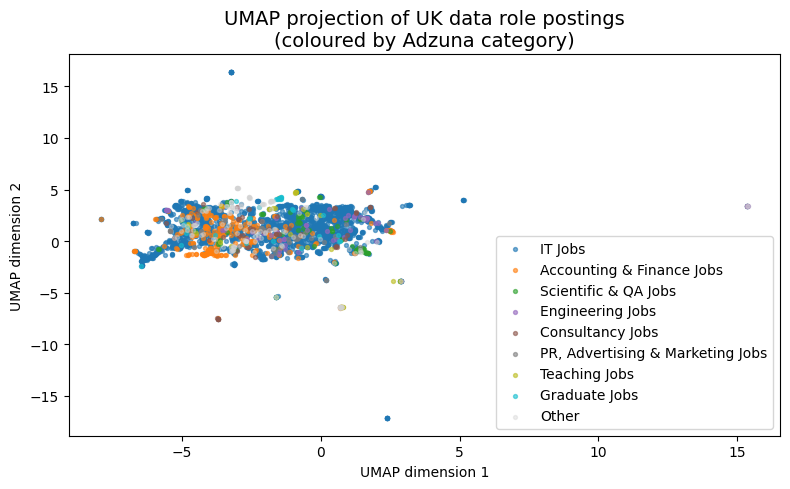

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Colour by category for first visual inspection
categories = df["category_label"].value_counts().head(8).index
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

for cat, color in zip(categories, colors):
    mask = df["category_label"] == cat
    ax.scatter(
        df.loc[mask, "umap_x"],
        df.loc[mask, "umap_y"],
        c=[color], label=cat, s=8, alpha=0.6
    )

# Anything not in top 8 categories
other_mask = ~df["category_label"].isin(categories)
if other_mask.any():
    ax.scatter(
        df.loc[other_mask, "umap_x"],
        df.loc[other_mask, "umap_y"],
        c="lightgrey", label="Other", s=8, alpha=0.4
    )

ax.set_title("UMAP projection of UK data role postings\n(coloured by Adzuna category)", fontsize=14)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.savefig("../docs/umap_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
import hdbscan

print("Running HDBSCAN clustering...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,      # smallest cluster we'll accept (we have 2,835 postings; 50 is ~1.8%)
    min_samples=10,           # how strict to be about cluster membership
    metric="euclidean",       # standard for 2D UMAP space
    cluster_selection_method="eom"  # excess of mass (recommended)
)

cluster_labels = clusterer.fit_predict(embeddings_2d)
df["cluster"] = cluster_labels

# How many clusters did we get? -1 means "noise / unclustered"
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

print(f"\n✓ Clustering complete")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points (unclustered): {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nCluster sizes:")
print(df["cluster"].value_counts().sort_index().to_string())

Running HDBSCAN clustering...

✓ Clustering complete
  Clusters found: 3
  Noise points (unclustered): 302 (10.7%)

Cluster sizes:
cluster
-1     302
 0      92
 1    2390
 2      51


In [11]:
import umap
import hdbscan

print("Re-running UMAP with tighter parameters...")

# Tighter UMAP - look at very local structure
reducer2 = umap.UMAP(
    n_neighbors=5,       # was 15 - now looking at very close neighbours only
    min_dist=0.0,        # was 0.1 - now allows tight clusters
    n_components=2,
    metric="cosine",
    random_state=42
)

embeddings_2d_v2 = reducer2.fit_transform(embeddings)

print("Re-running HDBSCAN with smaller min cluster...")
clusterer2 = hdbscan.HDBSCAN(
    min_cluster_size=20,    # was 50 - now allows smaller clusters
    min_samples=5,          # was 10 - less strict
    metric="euclidean",
    cluster_selection_method="eom"
)

cluster_labels_v2 = clusterer2.fit_predict(embeddings_2d_v2)

n_clusters = len(set(cluster_labels_v2)) - (1 if -1 in cluster_labels_v2 else 0)
n_noise = (cluster_labels_v2 == -1).sum()

print(f"\n✓ Re-clustering complete")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels_v2).value_counts().sort_index().to_string())

Re-running UMAP with tighter parameters...
Re-running HDBSCAN with smaller min cluster...

✓ Re-clustering complete
  Clusters found: 52
  Noise points: 710 (25.0%)

Cluster sizes:
-1     710
 0      22
 1      49
 2      20
 3      21
 4      20
 5      33
 6      54
 7      42
 8      20
 9      29
 10     36
 11     75
 12     24
 13     55
 14     78
 15     27
 16     94
 17     22
 18     28
 19     31
 20     55
 21     22
 22     23
 23     25
 24     43
 25     25
 26     31
 27     52
 28     20
 29     37
 30     71
 31     79
 32     30
 33     50
 34     40
 35     25
 36     22
 37     70
 38     27
 39     80
 40     35
 41     43
 42    119
 43     38
 44     28
 45     37
 46     24
 47     47
 48     35
 49     43
 50     26
 51     43


In [12]:
# Re-embed using only titles
title_texts = df["title"].fillna("").tolist()
print(f"Embedding {len(title_texts)} titles only...")

title_embeddings = model.encode(title_texts, show_progress_bar=True, batch_size=32)

# Save these too
np.save("../data/processed/embeddings_titles_only.npy", title_embeddings)

# UMAP and HDBSCAN with sensible parameters
reducer_t = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric="cosine", random_state=42)
emb_2d_t = reducer_t.fit_transform(title_embeddings)

clusterer_t = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, metric="euclidean")
cluster_labels_t = clusterer_t.fit_predict(emb_2d_t)

n_clusters = len(set(cluster_labels_t)) - (1 if -1 in cluster_labels_t else 0)
n_noise = (cluster_labels_t == -1).sum()
print(f"\nTitle-only clustering:")
print(f"Clusters: {n_clusters}, Noise: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(pd.Series(cluster_labels_t).value_counts().sort_index().to_string())

Embedding 2835 titles only...


Batches:   0%|          | 0/89 [00:00<?, ?it/s]


Title-only clustering:
Clusters: 17, Noise: 356 (12.6%)
-1     356
 0     151
 1      86
 2     103
 3      74
 4     190
 5      80
 6     140
 7     119
 8     199
 9     235
 10    119
 11     89
 12    134
 13    463
 14     78
 15     73
 16    146


In [13]:
n_clusters = len(set(cluster_labels_t)) - (1 if -1 in cluster_labels_t else 0)
n_noise = (cluster_labels_t == -1).sum()
print(f"Clusters: {n_clusters}, Noise: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(pd.Series(cluster_labels_t).value_counts().sort_index().to_string())

Clusters: 17, Noise: 356 (12.6%)
-1     356
 0     151
 1      86
 2     103
 3      74
 4     190
 5      80
 6     140
 7     119
 8     199
 9     235
 10    119
 11     89
 12    134
 13    463
 14     78
 15     73
 16    146


In [14]:
# Save the title-based clustering as our working clustering
df["cluster"] = cluster_labels_t
df["umap_x"] = emb_2d_t[:, 0]
df["umap_y"] = emb_2d_t[:, 1]

# Look at top titles in each cluster
print("=" * 70)
for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue  # skip noise
    cluster_df = df[df["cluster"] == cluster_id]
    print(f"\nCLUSTER {cluster_id} — {len(cluster_df)} postings")
    print(f"  Top titles:")
    for title, count in cluster_df["title"].value_counts().head(5).items():
        print(f"    {count:>3}x  {title}")
    print(f"  Median salary: £{cluster_df['salary_midpoint'].median():,.0f}" if cluster_df['salary_midpoint'].notna().any() else "  Median salary: N/A")
print()


CLUSTER 0 — 151 postings
  Top titles:
     88x  Data Scientist
     10x  Head of Data Science
      5x  Data Science
      2x  Data Science Specialist
      2x  Data Scientist II
  Median salary: £60,000

CLUSTER 1 — 86 postings
  Top titles:
     37x  Data Engineer
      4x  Data Scientist - Water Sector
      3x  Data Science Engineer - MMM/Econometrics
      3x  Data Science Application Developer
      3x  Principal Data Scientist - Water Sector
  Median salary: £61,124

CLUSTER 2 — 103 postings
  Top titles:
     49x  Senior Data Scientist
      3x  Senior Data Scientist I
      2x  Data Scientist, Sports
      2x  Senior Data Scientist, Sports
      2x  Senior Applied Data Scientist
  Median salary: £59,723

CLUSTER 3 — 74 postings
  Top titles:
     19x  Business Intelligence Analyst
      5x  Business Intelligence Developer
      3x  Business Intelligence Developer - Temporary (up to 12 months)
      2x  SC & DV Cleared Data Consultants and Analysts
      2x  SC Cleared Perfor

In [15]:
df["cluster"] = cluster_labels_t
df["umap_x"] = emb_2d_t[:, 0]
df["umap_y"] = emb_2d_t[:, 1]

# Save the clustered dataframe
df.to_parquet("../data/processed/postings_clustered.parquet", index=False)
print(f"Saved: ../data/processed/postings_clustered.parquet")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")

Saved: ../data/processed/postings_clustered.parquet
Rows: 2835, Columns: 27


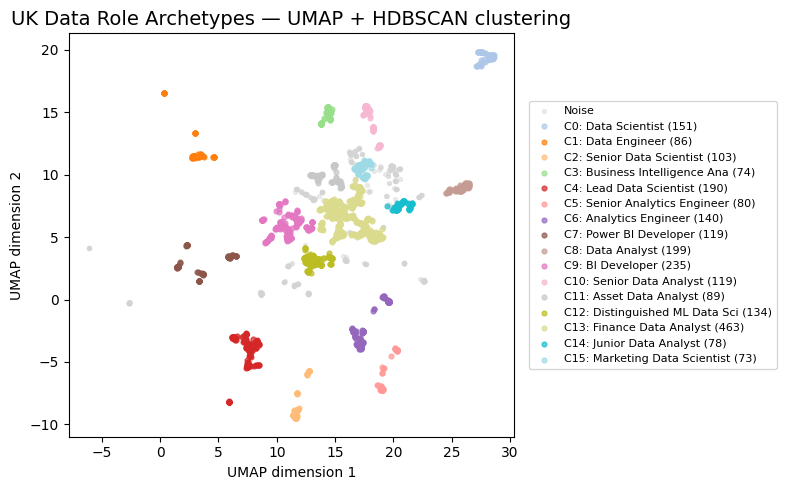

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Plot noise points first in light grey
noise_mask = df["cluster"] == -1
ax.scatter(df.loc[noise_mask, "umap_x"], df.loc[noise_mask, "umap_y"],
           c="lightgrey", s=8, alpha=0.4, label="Noise")

# Plot each cluster with a distinct colour
n_clusters = df["cluster"].nunique() - 1
cmap = plt.cm.tab20(np.linspace(0, 1, n_clusters))

for cluster_id, color in zip(sorted(df["cluster"].unique()), cmap):
    if cluster_id == -1:
        continue
    mask = df["cluster"] == cluster_id
    # Get the most common title for the label
    top_title = df.loc[mask, "title"].value_counts().index[0]
    ax.scatter(df.loc[mask, "umap_x"], df.loc[mask, "umap_y"],
               c=[color], s=12, alpha=0.7, 
               label=f"C{cluster_id}: {top_title[:25]} ({mask.sum()})")

ax.set_title("UK Data Role Archetypes — UMAP + HDBSCAN clustering", fontsize=14)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.savefig("../docs/clusters_named.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
cluster_labels_map = {
    -1: "Unclustered",
    0: "Data Scientist (mid-level)",
    1: "Data Engineer",
    2: "Senior Data Scientist",
    3: "BI / Reporting Analyst",
    4: "Lead / Principal",
    5: "Senior Analytics / Principal Data",
    6: "Analytics Engineer / Data Manager",
    7: "Power BI / Microsoft stack",
    8: "Data Analyst",
    9: "Senior Engineer / Architect (mixed)",
    10: "Senior Data Analyst / Governance",
    11: "Asset / MI / BI specialist",
    12: "AI / Machine Learning Engineer",
    13: "Domain-specific (Finance/Consulting)",
    14: "Junior / Graduate / Apprentice",
    15: "Marketing Data Scientist",
    16: "Business Data Analyst"
}

df["cluster_name"] = df["cluster"].map(cluster_labels_map)

# Build a summary table
summary = df.groupby("cluster_name").agg(
    n_postings=("id", "count"),
    median_salary=("salary_midpoint", "median"),
    top_title=("title", lambda s: s.value_counts().index[0]),
    n_companies=("company_name", "nunique")
).sort_values("median_salary", ascending=False)

print("Role archetype summary (sorted by median salary):\n")
print(summary.to_string())

# Save the labelled dataframe
df.to_parquet("../data/processed/postings_clustered.parquet", index=False)

Role archetype summary (sorted by median salary):

                                      n_postings  median_salary                        top_title  n_companies
cluster_name                                                                                                 
AI / Machine Learning Engineer               134       74416.47  Distinguished ML Data Scientist          100
Senior Analytics / Principal Data             80       69302.17        Senior Analytics Engineer           66
Senior Engineer / Architect (mixed)          235       66289.62                     BI Developer          174
Lead / Principal                             190       65066.79              Lead Data Scientist          129
Analytics Engineer / Data Manager            140       61822.46               Analytics Engineer          105
Data Engineer                                 86       61124.30                    Data Engineer           63
Data Scientist (mid-level)                   151       60000.00      